# Data Exploration & Preprocessing
**Project:** Forecasting Energy Surplus for Renewable Energy Services (Brighton & Colchester)
**Project:** Renewable Energy Forecasting

## 1. Project Background and Objectives
This notebook covers the loading, cleaning, feature engineering, and exploration of weather datasets for **Brighton** and **Colchester**. The ultimate goal is to build a reliable predictive system to forecast energy surplus at least 24 hours in advance. To achieve this, we:
1. Combine raw historical weather files from 2010 to 2024.
2. Address data completeness (missing hours) and cleaning (duplicate records).
3. Model theoretical **Wind Energy** and **Solar Energy** generation based on physical equations and engineering assumptions.
4. Prepare train and test datasets chronologically to prevent target leakage.

## 2. Environment Setup & Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from statsmodels.tsa.stattools import adfuller

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Data Loading and Formatting
We write a helper function to merge the individual monthly CSV files for each location. Some files have an extra numeric index row at the top (`0, 1, 2...`), which we skip dynamically if the first column is numeric.

In [2]:
def load_and_combine_data(pattern):
    files = glob.glob(pattern)
    df_list = []
    print(f"Found {len(files)} files matching pattern '{pattern}'")
    for file in sorted(files):
        # Peek to check if the header has digit names (e.g. index row)
        df_peek = pd.read_csv(file, nrows=2)
        if df_peek.columns[0].isdigit():
            df = pd.read_csv(file, skiprows=1)
        else:
            df = pd.read_csv(file)
        
        df.columns = [c.strip() for c in df.columns]
        df_list.append(df)
    
    combined = pd.concat(df_list, axis=0, ignore_index=True)
    combined['datetime'] = pd.to_datetime(combined['datetime'])
    combined = combined.sort_values(by='datetime').reset_index(drop=True)
    return combined

In [3]:
print("Loading Brighton weather data...")
brighton_raw = load_and_combine_data("data/brighton_*.csv")
print(f"Brighton raw shape: {brighton_raw.shape}\n")

print("Loading Colchester weather data...")
colchester_raw = load_and_combine_data("data/colchester_*.csv")
print(f"Colchester raw shape: {colchester_raw.shape}")

Loading Brighton weather data...
Found 128 files matching pattern 'data/brighton_*.csv'
Brighton raw shape: (122844, 16)

Loading Colchester weather data...
Found 196 files matching pattern 'data/colchester_*.csv'
Colchester raw shape: (188024, 16)


## 4. Preprocessing Pipeline
To build a robust time-series forecasting model, we define a cleaning pipeline that:
1. Filters the data from **2010-01-01** onwards (to ensure both locations have consistent wind and solar weather features).
2. Detects and removes duplicate timestamps.
3. Reindexes the dataset to a complete hourly grid. This creates `NaN` placeholders for any missing hours.
4. Corrects the interpolation logic: we call `.interpolate(method='linear')` on the `NaN` values to realistically fill weather features (temperature, pressure, etc.), avoiding the original bug that hardcoded missing hours to `0` prior to interpolation.

In [4]:
def clean_and_preprocess(df, name):
    print(f"=== Preprocessing {name} ===")
    # Filter to 2010 onwards for solar/wind consistency
    df = df[df['datetime'] >= '2010-01-01'].copy()
    
    # Duplicate removal
    df.set_index('datetime', inplace=True)
    duplicates = df.index[df.index.duplicated()]
    if len(duplicates) > 0:
        print(f"Found {len(duplicates)} duplicate timestamps. Removing duplicates (keeping first)...")
        df = df[~df.index.duplicated(keep='first')]
    
    # Reindexing to full hourly frequency
    start_date = df.index.min().floor('H')
    end_date = df.index.max().ceil('H')
    full_range = pd.date_range(start=start_date, end=end_date, freq='H')
    missing_hours = len(full_range) - len(df)
    print(f"Expected hours: {len(full_range)}, Present hours: {len(df)}")
    print(f"Inserting {missing_hours} missing hours as NaNs")
    
    df = df.reindex(full_range)
    df.index.name = 'datetime'
    
    # Drop mostly empty weather columns
    cols_to_drop = ['preciptype', 'snow', 'snowdepth', 'solarenergy']
    df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    
    # Linear interpolation for weather columns (realistic continuity)
    for col in df.columns:
        df[col] = df[col].interpolate(method='linear').ffill().bfill()
        
    df.reset_index(inplace=True)
    print(f"Preprocessing complete. Shape: {df.shape}, NaNs: {df.isna().sum().sum()}\n")
    return df

In [5]:
brighton_clean = clean_and_preprocess(brighton_raw, "Brighton")
colchester_clean = clean_and_preprocess(colchester_raw, "Colchester")

=== Preprocessing Brighton ===
Found 14 duplicate timestamps. Removing duplicates (keeping first)...
Expected hours: 122844, Present hours: 122830
Inserting 14 missing hours as NaNs
Preprocessing complete. Shape: (122844, 12), NaNs: 0

=== Preprocessing Colchester ===
Found 13 duplicate timestamps. Removing duplicates (keeping first)...
Expected hours: 122818, Present hours: 105117
Inserting 17701 missing hours as NaNs
Preprocessing complete. Shape: (122818, 12), NaNs: 0



## 5. Energy Calculations & Assumptions

### 5.1 Wind Energy
We assume a wind farm consisting of **20 Horizontal Axis Wind Turbines (HAWT)**. Each turbine has a blade length of $L = 59.8\text{ m}$, yielding a sweep area of:
$$A = \pi \cdot L^2 \approx 11,234.4\text{ m}^2$$

The power generated by wind is calculated using the standard kinetic energy formulation:
$$E_w = \frac{1}{2} \rho A v^3 \cdot 20 \cdot \frac{1}{1000} \quad (\text{kW})$$
where:
- $\rho$ is the standard air density ($1.225\text{ kg/m}^3$).
- $v$ is wind speed in m/s (converted from kph in the dataset by multiplying by $0.27778$).

### 5.2 Solar Energy
We assume a **solar park** with a total active panel area of $A_{solar} = 5,000\text{ m}^2$ and an efficiency of $\eta = 18\% = 0.18$. The power generated is:
$$E_s = A_{solar} \cdot \eta \cdot I_{radiation} \cdot \frac{1}{1000} \quad (\text{kW})$$
where:
- $I_{radiation}$ is the solar radiation in $\text{W/m}^2$.
- Solar radiation and UV index are clipped to `0` during night hours (before 6 AM and after 8 PM) to enforce physical correctness.

In [6]:
def add_energy_calculations(df):
    df = df.copy()
    df['hour'] = df['datetime'].dt.hour
    
    # Physical night constraints (solar is 0 between 8 PM and 6 AM)
    df.loc[(df['hour'] < 6) | (df['hour'] > 20), 'solarradiation'] = 0.0
    df.loc[(df['hour'] < 6) | (df['hour'] > 20), 'uvindex'] = 0.0
    
    # Wind Energy Calculation (kW)
    rho = 1.225
    L = 59.8
    A = np.pi * (L ** 2)
    df['windenergy'] = 0.5 * rho * A * ((df['windspeed'] * 0.27778) ** 3) * 20 / 1000.0
    
    # Solar Energy Calculation (kW)
    A_solar = 5000
    eta = 0.18
    df['solarenergy'] = A_solar * eta * df['solarradiation'] / 1000.0
    
    # Total Energy (kW)
    df['totalenergy'] = df['windenergy'] + df['solarenergy']
    return df

In [7]:
brighton_clean = add_energy_calculations(brighton_clean)
colchester_clean = add_energy_calculations(colchester_clean)
print("Energy columns added successfully.")

Energy columns added successfully.


## 6. Time Features and Cyclical Encoding
We extract time-based features (year, quarter, month, day, dayofweek) to capture seasonality. We also apply cyclical sine/cosine encodings to `hour` and `month` to allow machine learning models to capture the continuity between hour 23 and hour 0, and December and January.

In [8]:
def add_time_features(df):
    df = df.copy()
    df['year'] = df['datetime'].dt.year
    df['quarter'] = df['datetime'].dt.quarter
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['dayofweek'] = df['datetime'].dt.dayofweek
    
    # Cyclical encodings
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    return df

In [9]:
brighton_clean = add_time_features(brighton_clean)
colchester_clean = add_time_features(colchester_clean)
brighton_clean.head(2)

,datetime,temp,dew,humidity,precip,precipprob,windspeed,winddir,sealevelpressure,cloudcover,...,totalenergy,year,quarter,month,day,dayofweek,hour_sin,hour_cos,month_sin,month_cos
0,2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,19.4,11.0,999.9,62.2,...,21537.557003,2010,1,1,1,4,0.000000,1.000000,0.5,0.866025
1,2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,21.8,19.0,999.8,22.4,...,30560.519384,2010,1,1,1,4,0.258819,0.965926,0.5,0.866025


## 7. Exploratory Data Analysis & Visualizations

### 7.1 Compare Energy Generation Distributions
Let's compare the distributions of generated wind and solar energy at both locations.

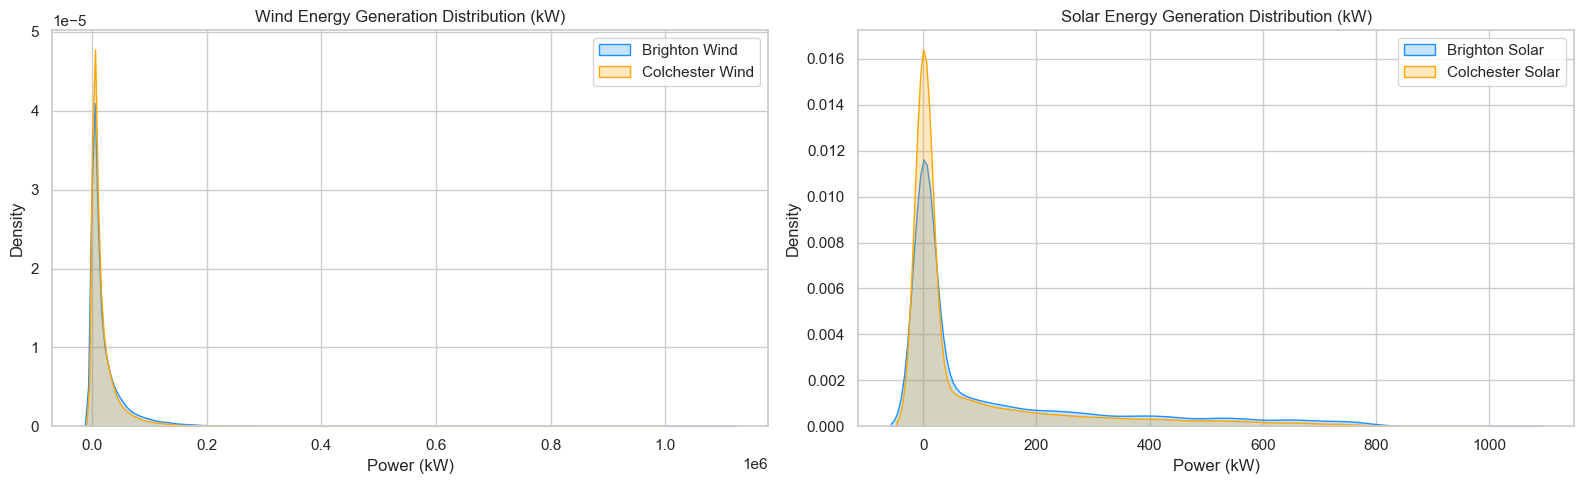

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.kdeplot(brighton_clean['windenergy'], ax=axes[0], fill=True, color='dodgerblue', label='Brighton Wind')
sns.kdeplot(colchester_clean['windenergy'], ax=axes[0], fill=True, color='orange', label='Colchester Wind')
axes[0].set_title("Wind Energy Generation Distribution (kW)")
axes[0].set_xlabel("Power (kW)")
axes[0].legend()

sns.kdeplot(brighton_clean['solarenergy'], ax=axes[1], fill=True, color='dodgerblue', label='Brighton Solar')
sns.kdeplot(colchester_clean['solarenergy'], ax=axes[1], fill=True, color='orange', label='Colchester Solar')
axes[1].set_title("Solar Energy Generation Distribution (kW)")
axes[1].set_xlabel("Power (kW)")
axes[1].legend()
plt.tight_layout()
plt.show()

### 7.2 Monthly Seasonality
Let's visualize the average monthly total power output for both locations. We expect wind energy to be stronger in winter, and solar energy to peak in summer.

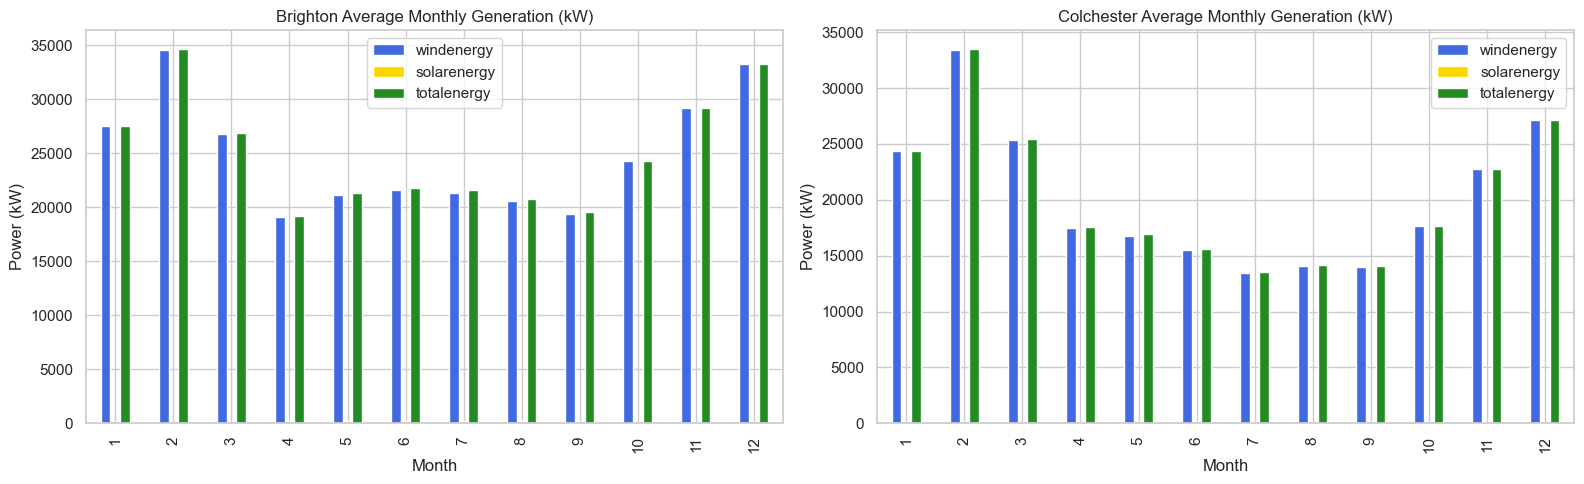

In [11]:
monthly_b = brighton_clean.groupby('month')[['windenergy', 'solarenergy', 'totalenergy']].mean().reset_index()
monthly_c = colchester_clean.groupby('month')[['windenergy', 'solarenergy', 'totalenergy']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly_b.plot(x='month', y=['windenergy', 'solarenergy', 'totalenergy'], kind='bar', ax=axes[0], color=['royalblue', 'gold', 'forestgreen'])
axes[0].set_title("Brighton Average Monthly Generation (kW)")
axes[0].set_ylabel("Power (kW)")
axes[0].set_xlabel("Month")
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(range(1, 13))

monthly_c.plot(x='month', y=['windenergy', 'solarenergy', 'totalenergy'], kind='bar', ax=axes[1], color=['royalblue', 'gold', 'forestgreen'])
axes[1].set_title("Colchester Average Monthly Generation (kW)")
axes[1].set_ylabel("Power (kW)")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(range(1, 13))
plt.tight_layout()
plt.show()

## 8. Stationarity Testing
We test the stationarity of our main target variables (`windspeed` and `solarradiation`) using the Augmented Dickey-Fuller (ADF) test. If the p-value is < 0.05, the null hypothesis is rejected, and the series is stationary.

In [12]:
def run_adf_test(series, name):
    print(f"Running ADF Test for {name}...")
    # Sample to speed up test execution
    result = adfuller(series.dropna().sample(20000, random_state=42))
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-Value: {result[1]:.4e}")
    if result[1] < 0.05:
        print("Conclusion: Stationary (reject H0)\n")
    else:
        print("Conclusion: Non-Stationary (fail to reject H0)\n")

In [13]:
run_adf_test(brighton_clean['windspeed'], "Brighton Windspeed")
run_adf_test(colchester_clean['windspeed'], "Colchester Windspeed")
run_adf_test(brighton_clean['solarradiation'], "Brighton Solar Radiation")
run_adf_test(colchester_clean['solarradiation'], "Colchester Solar Radiation")

Running ADF Test for Brighton Windspeed...
ADF Statistic: -64.6844
P-Value: 0.0000e+00
Conclusion: Stationary (reject H0)

Running ADF Test for Colchester Windspeed...
ADF Statistic: -82.3099
P-Value: 0.0000e+00
Conclusion: Stationary (reject H0)

Running ADF Test for Brighton Solar Radiation...
ADF Statistic: -141.2599
P-Value: 0.0000e+00
Conclusion: Stationary (reject H0)

Running ADF Test for Colchester Solar Radiation...
ADF Statistic: -141.9679
P-Value: 0.0000e+00
Conclusion: Stationary (reject H0)



## 9. Chronological Split and Data Saving
To train our models without lookahead target leakage, we split our data chronologically into 80% train and 20% test sets. We save the resulting clean files.

In [14]:
for name, df in [("brighton", brighton_clean), ("colchester", colchester_clean)]:
    split_idx = int(len(df) * 0.8)
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]
    
    train_df.to_csv(f'{name}_train_clean.csv', index=False)
    test_df.to_csv(f'{name}_test_clean.csv', index=False)
    print(f"Saved {name}_train_clean.csv (Shape: {train_df.shape}) and {name}_test_clean.csv (Shape: {test_df.shape})")

Saved brighton_train_clean.csv (Shape: (98275, 25)) and brighton_test_clean.csv (Shape: (24569, 25))
Saved colchester_train_clean.csv (Shape: (98254, 25)) and colchester_test_clean.csv (Shape: (24564, 25))
